<a href="https://colab.research.google.com/github/hpatel1933/AAI2025/blob/main/Hari_ML_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PART 1**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# Source:
# https://github.com/Sharma-Anshika/Bay-area-Real-Estate-analysis-/blob/main/RealestateData.csv

data_url = (
    "https://raw.githubusercontent.com/"
    "Sharma-Anshika/Bay-area-Real-Estate-analysis-/"
    "main/RealestateData.csv"
)

# Read the existing CSV file
# CHANGE FROM STARTER:
# The starter code manually created only 10 rows.
# This loads an existing online dataset instead.
df = pd.read_csv(data_url)

print("Number of rows:", len(df))
print("Column names:")
print(df.columns.tolist())

display(df.head())

Number of rows: 1528
Column names:
['Unnamed: 0', 'PropertyType', 'Address', 'City', 'State', 'ZipCode', 'Price', 'Beds', 'Baths', 'Living_Sq_Ft', 'Lot_Acres', 'YearBuilt', 'YearRenovated', 'Hoa/Month', 'Parking', 'Garage', 'last_sold_price', 'ElementarySchool', 'E.SchoolRating', 'MiddleSchool', 'M.schoolRating', 'HighSchool', 'H.SchoolRating', 'Heating', 'Cooling', 'WalkableScore', 'TransitScore', 'BikeableScore', 'RedfinEstimate', 'Status']


,Unnamed: 0,PropertyType,Address,City,State,ZipCode,Price,Beds,Baths,Living_Sq_Ft,...,M.schoolRating,HighSchool,H.SchoolRating,Heating,Cooling,WalkableScore,TransitScore,BikeableScore,RedfinEstimate,Status
0,house_0,Single Family Residential,123 E Rosemary Ln,CAMPBELL,CA,95008,1250000,3,2,"1,252",...,NaN,NaN,NaN,Gas,Window/Wall Unit,85.0,43.0,82.0,"$1,276,922",Active
1,house_1,Single Family Residential,165 Hunt Way,CAMPBELL,CA,95008,1275000,3,2,"1,331",...,NaN,NaN,NaN,Central Forced Air,Central Forced Air,31.0,33.0,53.0,"$1,269,365",Active
2,house_2,Single Family Residential,165 Hunt Way,CAMPBELL,CA,95008,1275000,3,2,"1,331",...,NaN,NaN,NaN,Central Forced Air,Central Forced Air,31.0,33.0,53.0,"$1,269,365",Active
3,house_3,Single Family Residential,673 Regas Dr,CAMPBELL,CA,95008,1989888,4,3,"3,500",...,8.0,NaN,NaN,Forced Air,Central Forced Air,74.0,44.0,85.0,"$2,095,588",Active
4,house_4,Condo/Co-op,850 Apricot Ave Unit A,CAMPBELL,CA,95008,799000,2,2,"1,065",...,8.0,NaN,NaN,Baseboard,Window/Wall Unit,68.0,45.0,82.0,"$800,898",Active


In [ ]:
# Remove unnecessary unnamed columns, if they exist
df = df.loc[
    :,
    ~df.columns.str.contains("^Unnamed")
]

# Keep the columns required for the assignment
df = df[
    ["Price", "Living_Sq_Ft", "City"]
].copy()

# Rename the columns to match the starter code
df = df.rename(
    columns={
        "Price": "price",
        "Living_Sq_Ft": "square_footage",
        "City": "location"
    }
)

# Convert price and square footage into numbers
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["square_footage"] = (
    df["square_footage"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

df["square_footage"] = pd.to_numeric(
    df["square_footage"],
    errors="coerce"
)

# Remove rows with missing values
df = df.dropna()

print("Rows after cleaning:", len(df))
display(df.head())

Rows after cleaning: 685


,price,square_footage,location
0,1250000,1252.0,CAMPBELL
1,1275000,1331.0,CAMPBELL
2,1275000,1331.0,CAMPBELL
3,1989888,3500.0,CAMPBELL
4,799000,1065.0,CAMPBELL


In [ ]:
# Display the actual cities available in the dataset
print("Available locations:")

for city in sorted(df["location"].unique()):
    print(city)

Available locations:
CAMPBELL
CUPERTINO
DALY CITY
EAST PALO ALTO
FREMONT
HAYWARD
LOS ALTOS
MENLO PARK
MILPITAS
MORGAN HILL
MOUNTAIN VIEW
NEWARK
PALO ALTO
PORTOLA VALLEY
SAN FRANCISCO
SAN JOSE
SAN LORENZO
SANTA CLARA
SARATOGA
SUNNYVALE
UNION CITY


In [ ]:
# Features used to make predictions
X = df[
    ["square_footage", "location"]
]

# Target variable being predicted
y = df["price"]

print("Features:")
display(X.head())

print("Target:")
display(y.head())

Features:


,square_footage,location
0,1252.0,CAMPBELL
1,1331.0,CAMPBELL
2,1331.0,CAMPBELL
3,3500.0,CAMPBELL
4,1065.0,CAMPBELL


Target:


,price
0,1250000
1,1275000
2,1275000
3,1989888
4,799000


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "location",
            OneHotEncoder(
                # CHANGE:
                # Leave one city out as the baseline location.
                # This makes the city coefficients easier to interpret.
                drop="first",
                handle_unknown="ignore"
            ),
            ["location"]
        )
    ],
    remainder="passthrough"
)

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train the linear regression model
model.fit(X_train, y_train)

print("The model has been trained successfully.")

The model has been trained successfully.


In [ ]:
# Make predictions using the testing data
test_predictions = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(
    y_test,
    test_predictions
)

r_squared = r2_score(
    y_test,
    test_predictions
)

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R-squared: {r_squared:.3f}")

Mean Absolute Error: $1,201,185.45
R-squared: -1.730


In [ ]:
# Select the most common real city in the dataset.
# This prevents us from accidentally using a city
# that does not exist in the data.
chosen_location = df["location"].mode()[0]

print("Location selected for the prediction:", chosen_location)

Location selected for the prediction: SAN JOSE


In [ ]:
# Make a prediction for a new 2,000-square-foot house
# in an actual Bay Area location.
new_house = pd.DataFrame({
    "square_footage": [2000],
    "location": [chosen_location]
})

predicted_price = model.predict(
    new_house
)[0]

print(
    f"Predicted price for a 2,000 sq. ft. house "
    f"in {chosen_location}: "
    f"${predicted_price:,.2f}"
)

Predicted price for a 2,000 sq. ft. house in SAN JOSE: $1,364,788.84


In [ ]:
# Get the feature names created by the preprocessing pipeline
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get the model coefficients
coefficients = (
    model
    .named_steps["regressor"]
    .coef_
)

# Rename the technical feature names to make them easier to read
readable_names = []

for feature in feature_names:

    if "square_footage" in feature:
        readable_names.append("Square Footage")

    elif "location_" in feature:
        city_name = feature.split("location_")[-1]
        readable_names.append(
            f"Location: {city_name}"
        )

    else:
        readable_names.append(feature)

# Create an easy-to-read table
coefficient_table = pd.DataFrame({
    "Feature": readable_names,
    "Coefficient": coefficients
})

# Format the coefficients as dollar amounts
coefficient_table["Coefficient"] = (
    coefficient_table["Coefficient"]
    .map(lambda value: f"${value:,.2f}")
)

print("Model Coefficients:")

display(coefficient_table)

Model Coefficients:


,Feature,Coefficient
0,Location: CAMPBELL,"$-1,944,836.92"
1,Location: CUPERTINO,"$-2,059,605.83"
2,Location: DALY CITY,"$-1,863,044.21"
3,Location: EAST PALO ALTO,"$-1,571,907.71"
4,Location: FREMONT,"$-2,113,556.08"
5,Location: HAYWARD,"$-2,904,587.61"
6,Location: LOS ALTOS,"$-1,386,314.36"
7,Location: MENLO PARK,"$-1,101,137.55"
8,Location: MILPITAS,"$-2,204,432.88"
9,Location: MORGAN HILL,"$-2,504,871.08"


# **PART 2**

In [40]:
from sklearn.preprocessing import StandardScaler

# Existing online dataset:
# IBM Telco Customer Churn Dataset
# Source:
# https://github.com/IBM/telco-customer-churn-on-icp4d/blob/master/data/Telco-Customer-Churn.csv

churn_url = (
    "https://raw.githubusercontent.com/"
    "IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)

churn_df = pd.read_csv(churn_url)

print("Number of rows:", len(churn_df))
print("Columns:")
print(churn_df.columns.tolist())

display(churn_df.head())

Number of rows: 7043
Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
# Convert TotalCharges to numeric.
# Some rows may contain blank values.
churn_df["TotalCharges"] = pd.to_numeric(
    churn_df["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing values
churn_df = churn_df.dropna()

# Convert Churn from Yes/No to 1/0
churn_df["churn"] = churn_df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Rows after cleaning:", len(churn_df))
display(churn_df.head())

Rows after cleaning: 7032


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [42]:
# Display all column names
print("Column names:")

for column in churn_df.columns:
    print(column)

Column names:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn
churn


In [43]:
# TotalCharges sometimes contains blank values.
# Convert it to a numeric column.
churn_df["TotalCharges"] = pd.to_numeric(
    churn_df["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing values
churn_df = churn_df.dropna().copy()

# Convert the target variable from Yes/No to 1/0
# 1 means the customer churned.
# 0 means the customer did not churn.
churn_df["churn"] = churn_df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Rows after cleaning:", len(churn_df))
print("\nChurn counts:")
print(churn_df["churn"].value_counts())

display(churn_df.head())

Rows after cleaning: 7032

Churn counts:
churn
0    5163
1    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [44]:
# CHANGE FROM STARTER:
# The starter code used age, monthly usage, purchase amount,
# service calls, and region.
#
# This real dataset does not contain those exact columns.
# Instead, we use relevant existing customer features.

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "PaperlessBilling"
]

# Define the input features
X = churn_df[
    numerical_features + categorical_features
]

# Define the target
y = churn_df["churn"]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'PaperlessBilling']


In [47]:
from sklearn.preprocessing import StandardScaler

# CHANGE FROM STARTER:
# StandardScaler is used for numerical features.
# OneHotEncoder is used for categorical features.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Create the logistic regression pipeline
churn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train the model
churn_model.fit(
    X_train,
    y_train
)

print("Logistic regression model trained successfully.")

Logistic regression model trained successfully.


In [49]:
from sklearn.metrics import accuracy_score

# Predict churn classifications for the test data
test_predictions = churn_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(f"Test Accuracy: {accuracy:.3f}")

Test Accuracy: 0.792


In [50]:
# Create a new customer for prediction
new_customer = pd.DataFrame({
    "tenure": [12],
    "MonthlyCharges": [70.00],
    "TotalCharges": [840.00],
    "Contract": ["Month-to-month"],
    "InternetService": ["Fiber optic"],
    "PaymentMethod": ["Electronic check"],
    "TechSupport": ["No"],
    "OnlineSecurity": ["No"],
    "PaperlessBilling": ["Yes"]
})

display(new_customer)

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,TechSupport,OnlineSecurity,PaperlessBilling
0,12,70.0,840.0,Month-to-month,Fiber optic,Electronic check,No,No,Yes


In [51]:
# Predict the probability of each possible outcome
probabilities = churn_model.predict_proba(
    new_customer
)

# The second value represents the probability of churn = 1
churn_probability = probabilities[0][1]

print(
    f"Churn Probability: {churn_probability:.2%}"
)

Churn Probability: 66.88%


In [52]:
# Use the required 0.50 threshold
threshold = 0.50

churn_prediction = int(
    churn_probability >= threshold
)

print(
    f"Churn Probability: {churn_probability:.2%}"
)

print(
    f"Churn Prediction: {churn_prediction}"
)

if churn_prediction == 1:
    print(
        "The customer is classified as being at risk of churn."
    )
else:
    print(
        "The customer is classified as unlikely to churn."
    )

Churn Probability: 66.88%
Churn Prediction: 1
The customer is classified as being at risk of churn.


In [53]:
# Get the feature names created by the preprocessing pipeline
feature_names = (
    churn_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get the logistic regression coefficients
coefficients = (
    churn_model
    .named_steps["classifier"]
    .coef_[0]
)

# Create a coefficient table
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Remove technical prefixes to make names easier to read
coefficient_table["Feature"] = (
    coefficient_table["Feature"]
    .str.replace(
        "numerical__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)

# Sort from the largest positive coefficient
# to the largest negative coefficient
coefficient_table = coefficient_table.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficient_table)

,Feature,Coefficient
2,TotalCharges,0.705773
5,InternetService_Fiber optic,0.561393
8,PaymentMethod_Electronic check,0.444178
14,PaperlessBilling_Yes,0.343584
1,MonthlyCharges,0.124337
9,PaymentMethod_Mailed check,0.045753
7,PaymentMethod_Credit card (automatic),0.038039
10,TechSupport_No internet service,-0.317447
6,InternetService_No,-0.317447
12,OnlineSecurity_No internet service,-0.317447


# **PART 3**

In [1]:
# Part 3: Customer Segmentation

# Install the package used to access the official UCI dataset
!pip -q install ucimlrepo

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Existing online dataset:
# Online Retail Dataset
# UCI Machine Learning Repository
#
# Source:
# https://archive.ics.uci.edu/dataset/352/online+retail

import requests
import zipfile
import io

# Official UCI download link
uci_url = (
    "https://archive.ics.uci.edu/static/public/"
    "352/online+retail.zip"
)

# Download the ZIP file
response = requests.get(uci_url)
response.raise_for_status()

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [11]:
# Open the downloaded ZIP file
with zipfile.ZipFile(
    io.BytesIO(response.content)
) as zip_file:

    print("Files inside the ZIP file:")
    print(zip_file.namelist())

    # Find the Excel file automatically
    excel_files = [
        file_name
        for file_name in zip_file.namelist()
        if file_name.lower().endswith(".xlsx")
    ]

    excel_file_name = excel_files[0]

    # Read the complete Excel file
    # This includes InvoiceNo, CustomerID, and all
    # other original columns.
    retail_df = pd.read_excel(
        io.BytesIO(
            zip_file.read(excel_file_name)
        )
    )

print("Number of transaction rows:", len(retail_df))
print("Column names:")
print(retail_df.columns.tolist())

display(retail_df.head())

Files inside the ZIP file:
['Online Retail.xlsx']
Number of transaction rows: 541909
Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
# Check how many missing values appear in each column
missing_values = retail_df.isnull().sum()

display(missing_values)

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [13]:
# Remove transactions without a CustomerID
retail_df = retail_df.dropna(
    subset=["CustomerID"]
).copy()

# Remove cancelled invoices.
# Cancelled invoices begin with the letter C.
retail_df = retail_df[
    ~retail_df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
].copy()

# Keep only transactions with positive quantities
# and positive prices.
retail_df = retail_df[
    (retail_df["Quantity"] > 0)
    & (retail_df["UnitPrice"] > 0)
].copy()

print(
    "Transaction rows after cleaning:",
    len(retail_df)
)

display(retail_df.head())

Transaction rows after cleaning: 397884


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
# Calculate the total value for each transaction line
retail_df["TotalPrice"] = (
    retail_df["Quantity"]
    * retail_df["UnitPrice"]
)

# Display the calculated transaction values
display(
    retail_df[
        [
            "CustomerID",
            "Quantity",
            "UnitPrice",
            "TotalPrice"
        ]
    ].head()
)

,CustomerID,Quantity,UnitPrice,TotalPrice
0,17850.0,6,2.55,15.30
1,17850.0,6,3.39,20.34
2,17850.0,8,2.75,22.00
3,17850.0,6,3.39,20.34
4,17850.0,6,3.39,20.34


In [15]:
# CHANGE FROM STARTER:
# The starter code manually created 10 customers.
# This version calculates customer information from
# the original UCI transaction records.

customer_df = (
    retail_df
    .groupby("CustomerID")
    .agg(
        annual_spending=("TotalPrice", "sum"),
        purchase_frequency=("InvoiceNo", "nunique"),
        total_items=("Quantity", "sum")
    )
    .reset_index()
)

print("Number of customers:", len(customer_df))
display(customer_df.head())

Number of customers: 4338


,CustomerID,annual_spending,purchase_frequency,total_items
0,12346.0,77183.60,1,74215
1,12347.0,4310.00,7,2458
2,12348.0,1797.24,4,2341
3,12349.0,1757.55,1,631
4,12350.0,334.40,1,197


In [16]:
# Review descriptive statistics
customer_df[
    [
        "annual_spending",
        "purchase_frequency",
        "total_items"
    ]
].describe()

,annual_spending,purchase_frequency,total_items
count,4338.000000,4338.000000,4338.000000
mean,2054.266460,4.272015,1191.289073
std,8989.230441,7.697998,5046.081546
min,3.750000,1.000000,1.000000
25%,307.415000,1.000000,160.000000
50%,674.485000,2.000000,379.000000
75%,1661.740000,5.000000,992.750000
max,280206.020000,209.000000,196915.000000


In [17]:
# Select the numerical features that will be used
# to group similar customers.
clustering_features = [
    "annual_spending",
    "purchase_frequency",
    "total_items"
]

print("Features used for clustering:")
print(clustering_features)

Features used for clustering:
['annual_spending', 'purchase_frequency', 'total_items']


In [18]:
# Scale the features so annual spending does not
# dominate the other variables because of its larger
# numerical values.
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    customer_df[clustering_features]
)

print("The clustering features have been standardized.")

The clustering features have been standardized.


In [19]:
# Test several possible numbers of clusters
k_values = range(1, 9)
inertia_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia_values.append(
        kmeans.inertia_
    )

print("Inertia values:")
print(inertia_values)

Inertia values:
[13014.000000000027, 6454.20773093423, 4780.783659021049, 3496.2354900697364, 2820.3438846541953, 2198.362530641307, 1769.852923640302, 1508.7180092916901]


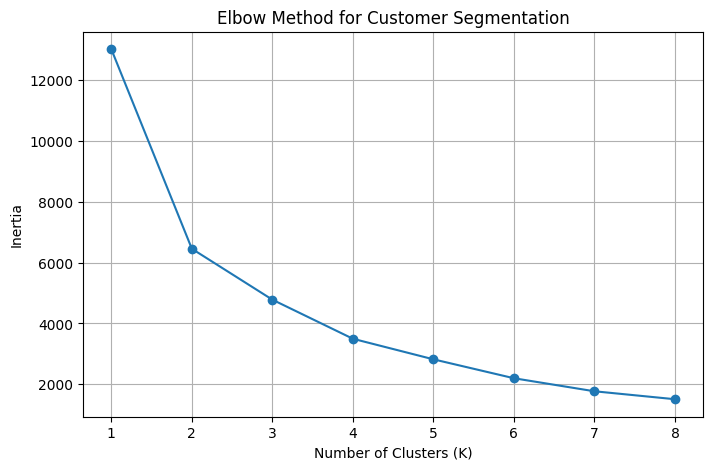

In [20]:
# Create the elbow plot
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [21]:
# Select K based on the elbow plot
optimal_k = 3

print(
    f"The selected number of clusters is K = {optimal_k}."
)

The selected number of clusters is K = 3.


In [22]:
# Create the final K-Means model
kmeans_model = KMeans(
    n_clusters=optimal_k,
    n_init=10,
    random_state=42
)

# Assign each customer to a cluster
customer_df["cluster"] = (
    kmeans_model.fit_predict(X_scaled)
)

display(customer_df.head())

,CustomerID,annual_spending,purchase_frequency,total_items,cluster
0,12346.0,77183.60,1,74215,1
1,12347.0,4310.00,7,2458,0
2,12348.0,1797.24,4,2341,0
3,12349.0,1757.55,1,631,0
4,12350.0,334.40,1,197,0


In [23]:
# Calculate the average customer behavior
# within each cluster
cluster_summary = (
    customer_df
    .groupby("cluster")[clustering_features]
    .mean()
    .round(2)
)

print("Average Characteristics by Cluster:")

display(cluster_summary)

Average Characteristics by Cluster:


,annual_spending,purchase_frequency,total_items
cluster,,,
0,1378.99,3.71,805.53
1,161916.87,54.44,85146.33
2,31069.47,43.36,19092.82


In [24]:
# Count the number of customers in every cluster
cluster_sizes = (
    customer_df["cluster"]
    .value_counts()
    .sort_index()
    .rename("number_of_customers")
)

display(cluster_sizes)

,number_of_customers
cluster,
0,4279
1,9
2,50


In [25]:
# Calculate median values to help identify
# high and low customer behavior.
spending_median = cluster_summary[
    "annual_spending"
].median()

frequency_median = cluster_summary[
    "purchase_frequency"
].median()

for cluster, row in cluster_summary.iterrows():

    spending = row["annual_spending"]
    frequency = row["purchase_frequency"]
    items = row["total_items"]

    print(f"Cluster {cluster}")
    print(f"Average spending: £{spending:,.2f}")
    print(f"Average purchase frequency: {frequency:.2f}")
    print(f"Average number of items: {items:.2f}")

    if spending >= spending_median:
        strategy = (
            "High-value customers: provide VIP rewards, "
            "exclusive promotions, and early product access."
        )

    elif frequency >= frequency_median:
        strategy = (
            "Frequent customers: provide subscriptions, "
            "replenishment reminders, and volume discounts."
        )

    else:
        strategy = (
            "Lower-engagement customers: send re-engagement "
            "emails, introductory offers, and product recommendations."
        )

    print("Recommended strategy:")
    print(strategy)
    print()

Cluster 0
Average spending: £1,378.99
Average purchase frequency: 3.71
Average number of items: 805.53
Recommended strategy:
Lower-engagement customers: send re-engagement emails, introductory offers, and product recommendations.

Cluster 1
Average spending: £161,916.87
Average purchase frequency: 54.44
Average number of items: 85146.33
Recommended strategy:
High-value customers: provide VIP rewards, exclusive promotions, and early product access.

Cluster 2
Average spending: £31,069.47
Average purchase frequency: 43.36
Average number of items: 19092.82
Recommended strategy:
High-value customers: provide VIP rewards, exclusive promotions, and early product access.



In [26]:
# Save the customer-level data and cluster assignments
customer_df.to_csv(
    "customer_segments.csv",
    index=False
)

print(
    "The segmentation results were saved as "
    "customer_segments.csv."
)

The segmentation results were saved as customer_segments.csv.


In [27]:
from google.colab import files

files.download(
    "customer_segments.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Extra Credit**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [31]:
# Existing online dataset:
# Housing Inventory: Active Listing Count in California
# Federal Reserve Economic Data (FRED)
# Original source: Realtor.com
#
# Source:
# https://fred.stlouisfed.org/series/ACTLISCOUCA

california_url = (
    "https://fred.stlouisfed.org/graph/"
    "fredgraph.csv?id=ACTLISCOUCA"
)

# Load the existing CSV file
california_df = pd.read_csv(
    california_url
)

print(
    "Number of rows:",
    len(california_df)
)

print("Original columns:")
print(california_df.columns.tolist())

display(california_df.head())

Number of rows: 122
Original columns:
['observation_date', 'ACTLISCOUCA']


,observation_date,ACTLISCOUCA
0,2016-07-01,83904
1,2016-08-01,84217
2,2016-09-01,82769
3,2016-10-01,79935
4,2016-11-01,74465


In [32]:
# Remove extra spaces from column names
california_df.columns = (
    california_df.columns
    .str.strip()
)

# Rename the date column.
# FRED normally uses the name DATE.
california_df = california_df.rename(
    columns={
        "DATE": "date",
        "observation_date": "date"
    }
)

# Rename the FRED data column
california_df = california_df.rename(
    columns={
        "ACTLISCOUCA": "active_listings"
    }
)

# Convert the date column to datetime format
california_df["date"] = pd.to_datetime(
    california_df["date"]
)

# Convert active listings to numeric values
california_df["active_listings"] = pd.to_numeric(
    california_df["active_listings"],
    errors="coerce"
)

# Remove missing values
california_df = california_df.dropna()

# Sort the data chronologically
california_df = california_df.sort_values(
    by="date"
).reset_index(drop=True)

print(
    "Rows after cleaning:",
    len(california_df)
)

display(california_df.head())

Rows after cleaning: 122


,date,active_listings
0,2016-07-01,83904
1,2016-08-01,84217
2,2016-09-01,82769
3,2016-10-01,79935
4,2016-11-01,74465


In [33]:
print(
    "Beginning date:",
    california_df["date"].min()
)

print(
    "Ending date:",
    california_df["date"].max()
)

print(
    "Minimum active listings:",
    california_df["active_listings"].min()
)

print(
    "Maximum active listings:",
    california_df["active_listings"].max()
)

display(
    california_df[
        ["date", "active_listings"]
    ].describe()
)

Beginning date: 2016-07-01 00:00:00
Ending date: 2026-08-01 00:00:00
Minimum active listings: 22698
Maximum active listings: 86995


,date,active_listings
count,122,122.000000
mean,2021-07-16 19:04:55.081967104,56871.401639
min,2016-07-01 00:00:00,22698.000000
25%,2019-01-08 18:00:00,43148.000000
50%,2021-07-16 12:00:00,57789.000000
75%,2024-01-24 06:00:00,70736.250000
max,2026-08-01 00:00:00,86995.000000
std,NaN,16683.224593


In [34]:
# Machine-learning models cannot directly use dates.
# Create a sequential month number instead.
california_df["month_number"] = np.arange(
    len(california_df)
)

display(california_df.head())

,date,active_listings,month_number
0,2016-07-01,83904,0
1,2016-08-01,84217,1
2,2016-09-01,82769,2
3,2016-10-01,79935,3
4,2016-11-01,74465,4


In [35]:
# Use month number as the input feature
X = california_df[
    ["month_number"]
]

# Use active listings as the target variable
y = california_df[
    "active_listings"
]

# Keep the final 20% of the data for testing.
# This preserves the time order.
split_point = int(
    len(california_df) * 0.80
)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 97
Testing rows: 25


In [36]:
# Create a linear regression model
california_model = LinearRegression()

# Train the model using historical California data
california_model.fit(
    X_train,
    y_train
)

print(
    "California housing inventory model trained."
)

California housing inventory model trained.


In [37]:
# Predict active listings for the test period
test_predictions = california_model.predict(
    X_test
)

# Calculate the average prediction error
mae = mean_absolute_error(
    y_test,
    test_predictions
)

print(
    f"Test Mean Absolute Error: {mae:,.2f} listings"
)

print(
    "Monthly trend coefficient:",
    round(california_model.coef_[0], 2)
)

Test Mean Absolute Error: 36,106.35 listings
Monthly trend coefficient: -436.81


In [38]:
# Retrain the model using all available historical data
# before making the future forecast.
final_model = LinearRegression()

final_model.fit(
    X,
    y
)

print(
    "Final model trained using all historical data."
)

Final model trained using all historical data.


In [39]:
# Create six future month numbers
future_month_numbers = np.arange(
    len(california_df),
    len(california_df) + 6
)

# Create six future dates
future_dates = pd.date_range(
    start=california_df["date"].max()
    + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

# Put the future month numbers into a DataFrame
future_input = pd.DataFrame({
    "month_number": future_month_numbers
})

display(future_input)

,month_number
0,122
1,123
2,124
3,125
4,126
5,127


In [40]:
# Predict active listings for the next six months
forecast_values = final_model.predict(
    future_input
)

# Active listings cannot be negative
forecast_values = np.maximum(
    forecast_values,
    0
)

# Round the predictions
forecast_values = np.round(
    forecast_values,
    0
).astype(int)

# Create the forecast table
forecast_df = pd.DataFrame({
    "month": future_dates,
    "forecast_active_listings": forecast_values
})

display(forecast_df)

,month,forecast_active_listings
0,2026-09-01,48291
1,2026-10-01,48151
2,2026-11-01,48011
3,2026-12-01,47872
4,2027-01-01,47732
5,2027-02-01,47593


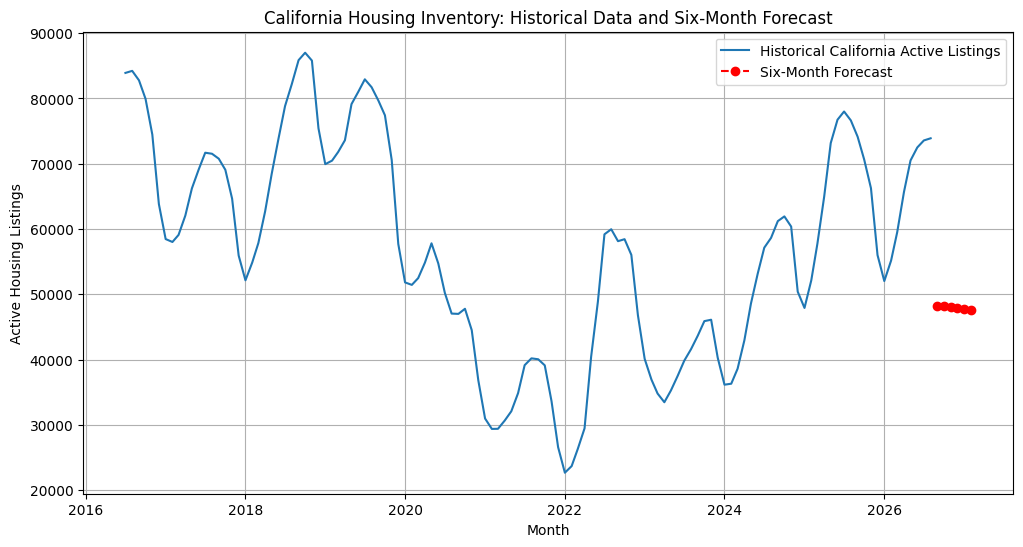

In [41]:
plt.figure(figsize=(12, 6))

# Plot historical California active listings
plt.plot(
    california_df["date"],
    california_df["active_listings"],
    label="Historical California Active Listings"
)

# Plot the six-month forecast
plt.plot(
    forecast_df["month"],
    forecast_df["forecast_active_listings"],
    marker="o",
    linestyle="--",
    color="red",
    label="Six-Month Forecast"
)

plt.xlabel("Month")

plt.ylabel(
    "Active Housing Listings"
)

plt.title(
    "California Housing Inventory: "
    "Historical Data and Six-Month Forecast"
)

plt.legend()
plt.grid(True)

plt.show()

In [42]:
# Save the six-month forecast as a CSV file
forecast_df.to_csv(
    "california_six_month_forecast.csv",
    index=False
)

print(
    "The forecast was saved as "
    "california_six_month_forecast.csv."
)

The forecast was saved as california_six_month_forecast.csv.


In [43]:
from google.colab import files

files.download(
    "california_six_month_forecast.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>